In [10]:
"""Simulate representative autaptic currents for the peak-current panel."""

import numpy as np
import pandas as pandas
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# AQUA supplies the neuron/autapse model wrapper used to build Brian2 objects.
import aqua
from aqua.batchAQUA_general import batchAQUA

# Brian2 units, monitors, and network primitives are imported into the namespace.
from brian2 import *


In [11]:
# Reset Brian2 state so repeated notebook runs start from a clean simulation.
start_scope()

N_neurons = 5

# Regular-spiking Izhikevich-style parameter set used for every simulated cell.
RS = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 150., 'tau': 0.5}    # Class 1

# Autapse rise/decay constants and peak currents chosen to span excitatory and
# inhibitory examples reported in the literature.
t_a1 = np.ones(N_neurons)
t_a2 = np.array([5, 5, 7.3, 4, 3.6])
I_peak = np.array([150, 30, -150, -250, -450])

T = 500     # ms
dt = 0.01    # ms
N_iter = int(T/dt)

# Build one identical model parameter row per simulated neuron and initialise all
# cells at rest with no adaptation/autapse state carried over.
params = []
x_start = np.zeros((N_neurons, 3))
t_start = np.zeros(N_neurons)
for i in range(N_neurons):
    params.append(RS)
    x_start[i] = np.array([-60., 0., 0.])

param_df = pd.DataFrame(params)

batch = batchAQUA(param_df)
batch.Initialise(x_start, t_start)

# Constant injected current drives the model; Brian2 consumes the array as a
# TimedArray with shape (time, neuron).
I_inj = 80.*np.ones((N_neurons, N_iter))
I_inj[5:, :] *= 1.3

I_injTA = TimedArray(values = I_inj.T, dt = dt*ms, name = 'I_injTA')

# Convert AQUA batch definitions into a Brian2 neuron group plus autapse synapses.
G, autapses = batch.meetBrian(stimulus_name = I_injTA, autapse_type = 'biexponential', t_a1 = t_a1, t_a2 = t_a2, I_peak = I_peak)

print("G T")
print(G.t_a1)
print(G.t_a2)

# Record voltage, autaptic current/state, and spike timing for plotting.
defaultclock.dt = dt*ms
M_v = StateMonitor(G, 'v', record = 0)
M_w = StateMonitor(G, 'w', record = True)
spikemon = SpikeMonitor(G, record = True)
net = Network(G, autapses, M_v, M_w, spikemon)
plt.show()

# Run the configured network once monitors and synapses are attached.
net.run(T*ms)




G T
<neurongroup.t_a1: array([1., 1., 1., 1., 1.])>
<neurongroup.t_a2: array([5. , 5. , 7.3, 4. , 3.6])>


- - SPIKEMON - -
[ 0.          0.          0.         ... 14.41303956 14.38424311
 14.35550418]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.52929865e-07
 1.52624311e-07 1.52319367e-07]
[ 0.          0.          0.         ... -0.04040938 -0.04035406
 -0.04029882]
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -3.73102786e-05
 -3.72171195e-05 -3.71241930e-05]
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -7.77874134e-05
 -7.75716373e-05 -7.73564598e-05]


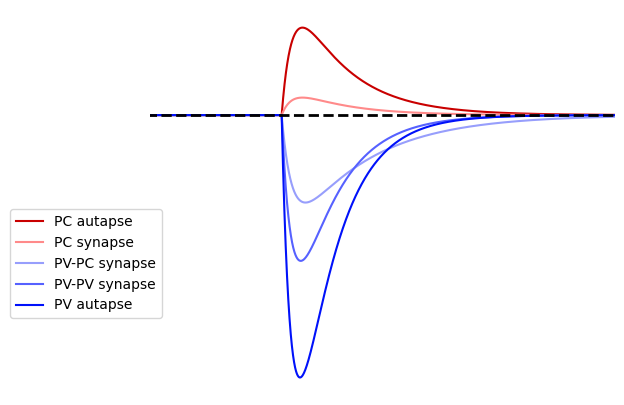

In [31]:
print("- - SPIKEMON - -")

#print(f"brian2: {spikemon.t[:].reshape((N_neurons, -1), order = 'F')[0]}")

fig, ax = plt.subplots(1, 1, figsize = (6, 5))

# Remove all frame elements so the exported panel only shows the current traces.
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.spines.left.set_visible(False)
ax.spines.bottom.set_visible(False)

x_lim = (60, 105)
I_peak = np.array([150, 30, -150, -250, -450])

# Trace colors encode the sign and class of the example current.
col_dict = {0: [0.788, 0, 0, 1], 1: [1, 0.541, 0.541, 1], 2: [0.592, 0.62, 0.988, 1],
            3: [0.337, 0.38, 1, 1], 4: [0, 0.067, 0.98, 1]}
labels_dict = {0: "PC autapse", 1: "PC synapse", 2: "PV-PC synapse", 3: "PV-PV synapse", 4: "PV autapse"}

for n, row in enumerate(M_w.w):
    # Plot each recorded autaptic current waveform against simulation time.
    print(row)
    ax.plot(M_w.t/ms, row, color = col_dict[n], label = labels_dict[n])

# Zero line separates inward and outward current examples.
ax.hlines(y = 0, xmin = ax.get_xlim()[0], xmax = ax.get_xlim()[1], linestyle = '--', color = 'black', linewidth = 2)
ax.legend(loc = (-0.3, 0.2))
ax.set_xlim(x_lim)
ax.set_xticks([])
ax.set_yticks([])
plt.savefig(".//peak_currents.svg")
